# Análise exploratória das bases de dados

## Instalação e importação de bibliotecas

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

In [ ]:
pip install statsmodels

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

## Análise exploratória da base de dados de todas as regiões

In [23]:
df_regioes = pd.read_csv("datasets/consumo_energia_regioes_limpo.csv")
display(df_regioes.head())
display(df_regioes.info())

,ano,mes,regiao,tipo_consumo,consumo,data
0,2015,1,Centro-Oeste,Cativo,2414412,2015-01-01
1,2015,1,Centro-Oeste,Comercial,607356,2015-01-01
2,2015,1,Centro-Oeste,Industrial,677273,2015-01-01
3,2015,1,Centro-Oeste,Outros,583718,2015-01-01
4,2015,1,Centro-Oeste,Residencial,989503,2015-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ano           3240 non-null   int64 
 1   mes           3240 non-null   int64 
 2   regiao        3240 non-null   object
 3   tipo_consumo  3240 non-null   object
 4   consumo       3240 non-null   int64 
 5   data          3240 non-null   object
dtypes: int64(3), object(3)
memory usage: 152.0+ KB


None

### Verificação inicial

#### * Consistência categórica (se os nomes dos dados estão padronizados)
#### * Valores nulos
#### * Tipagem: neste caso, se a coluna **data** apresenta o tipo correto para as análises de séries temporais (datetime do Pandas)

In [29]:
#Verificando os nomes das regiões
print("Regiões encontradas no dataset")
print(df_regioes['regiao'].unique())

#Verificando os tipos de consumo
print("\nTipos de consumo encontrados")
print(df_regioes['tipo_consumo'].unique())

# Uma contagem rápida para ver se a distribuição faz sentido
print("\nContagem de registros por tipo de consumo ---")
print(df_regioes['tipo_consumo'].value_counts())

Regiões encontradas no dataset
['Centro-Oeste' 'Nordeste' 'Norte' 'Sudeste' 'Sul']

Tipos de consumo encontrados
['Cativo' 'Comercial' 'Industrial' 'Outros' 'Residencial' 'Total']

Contagem de registros por tipo de consumo ---
tipo_consumo
Cativo         540
Comercial      540
Industrial     540
Outros         540
Residencial    540
Total          540
Name: count, dtype: int64


#### Segundo a análise, o nome tanto das regiões quanto dos tipos de consumo estão consistentes e padronizados, portanto não será necessário tratar estas colunas. 

In [31]:
df_regioes["ano"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

#### Observando os valores únicos da coluna **ano**, percebe-se que somente os dados de 2015 até 2023 estão disponíveis. Portanto, temos dados de 8 anos para analisar.

#### Mas será que o ano de 2023 veio completo? O código abaixo nos mostra de todos os 12 meses constam neste ano para cada região brasileira.

In [33]:
# Filtrar apenas o ano de 2023 e o consumo residencial
df_2023 = df_regioes[(df_regioes['ano'] == 2023) & (df_regioes['tipo_consumo'] == 'Residencial')]

# Identificar a coluna de agrupamento (região ou estado)
coluna_grupo = 'regiao' if 'regiao' in df_regioes.columns else 'sigla_uf'

# Contar quantos meses únicos existem para cada localidade
verificacao_meses = df_2023.groupby(coluna_grupo)['mes'].nunique()

print(f"Verificação de meses em 2023 (agrupado por {coluna_grupo})")
print(verificacao_meses)

# 4. Mostrar explicitamente quais meses estão na base
meses_presentes = sorted(df_2023['mes'].unique())
print(f"\nMeses encontrados: {meses_presentes}")

Verificação de meses em 2023 (agrupado por regiao)
regiao
Centro-Oeste    12
Nordeste        12
Norte           12
Sudeste         12
Sul             12
Name: mes, dtype: int64

Meses encontrados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


### Os dados que realmente nos interessam na nossa análise são os do consumo residencial, portanto vamos verificar somente esses dados.

#### Verificando a saúde dos dados: Buscando valores faltantes

In [30]:
# Filtrando apenas o consumo residencial
df_regioes_residencial = df_regioes[df_regioes['tipo_consumo'] == 'Residencial'].copy()

# Verificando se existem dados nulos (NaN)
print("Verificação de dados faltantes")
print(df_regioes_residencial.isnull().sum())

Verificação de dados faltantes
ano             0
mes             0
regiao          0
tipo_consumo    0
consumo         0
data            0
dtype: int64


Observação:
O conjunto de dados apresenta alta integridade, com ausência total de valores nulos (missing values). Isso elimina a necessidade de técnicas de imputação que poderiam comprometer a análise das séries temporais.

#### Tratamento necessário para analisar os componentes da série temporal: converter a coluna "data" para o tipo datetime.

In [27]:
df_regioes['data'] = pd.to_datetime(df_regioes['data'])

In [28]:
#verificando se a conversão foi realizada
df_regioes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ano           3240 non-null   int64         
 1   mes           3240 non-null   int64         
 2   regiao        3240 non-null   object        
 3   tipo_consumo  3240 non-null   object        
 4   consumo       3240 non-null   int64         
 5   data          3240 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 152.0+ KB


Vamos definir a coluna **data** como índice.

In [15]:
df_regioes.set_index('data', inplace=True)

## Análise dos componentes das séries temporais

#### A análise dos componentes das séries temporais foi baseada no livro *Forecasting: Principals and Practice*, de Hyndman e Athanasopoulos.

#### No que consistem as séries temporais?

Uma série temporal consiste em uma sequência de dados ou observações coletadas em intervalos de tempo sucessivos e constantes. Neste tipo de análise, o aspecto cronológico é o que define a estrutura do dado, onde a ordem das observações é fundamental para identificar padrões de dependência temporal e realizar previsões sobre o comportamento futuro da variável estudada (HYNDMAN; ATHANASOPOULOS, 2021).

#### Com o objetivo de conhecer melhor os dados relevantes para o nosso problema, vamos nos aprofundar no comportamento temporal do consumo de energia residencial de cada região do Brasil e realizar uma análise comparativa.

### Os componentes da decomposição

Na decomposição da série temporal desmembramos a série original em componentes individuais para facilitar a compreensão dos padrões. 
Segundo a metodologia clássica, esses componentes são:

* Tendência: Representa a direção de longo prazo dos dados, indicando se há um aumento ou uma diminuição sistemática no nível da série ao longo do tempo. A tendência não precisa ser linear, podendo mudar de direção ao longo de períodos extensos (HYNDMAN; ATHANASOPOULOS, 2021).

* Sazonalidade: Refere-se às oscilações que ocorrem em intervalos regulares e fixos, influenciadas por fatores sazonais como o calendário anual (meses, trimestres), semanal ou até diário. É um padrão previsível que se repete com a mesma frequência no decorrer da série (HYNDMAN; ATHANASOPOULOS, 2021).

* Resíduo ou erro: Representa o que resta da série após a remoção da tendência e da sazonalidade. **Engloba as variações aleatórias, ruídos e eventos imprevisíveis que não seguem um padrão, sendo a parte da série que não pode ser explicada pelo modelo** (HYNDMAN; ATHANASOPOULOS, 2021).

### Justificativa do modelo multiplicativo

A escolha entre o modelo aditivo e o multiplicativo depende da relação entre a sazonalidade e a tendência. O modelo multiplicativo é o mais adequado quando a amplitude das variações sazonais aumenta ou diminui proporcionalmente ao nível da tendência. No contexto do consumo energético, à medida que a demanda-base (tendência) cresce, os picos de consumo sazonal tendem a se tornar mais acentuados, justificando a aplicação desta abordagem neste projeto (HYNDMAN; ATHANASOPOULOS, 2021).

#### Decomposição da região Nordeste

In [38]:
# Criando um filtro para isolar a série que queremos analisar
filtro = (df_regioes['regiao'] == 'Nordeste') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_nordeste_res = df_regioes[filtro]['consumo']


print(serie_nordeste_res.head())

10     2302666
40     2240786
70     2213527
100    2232375
130    2218162
Name: consumo, dtype: int64


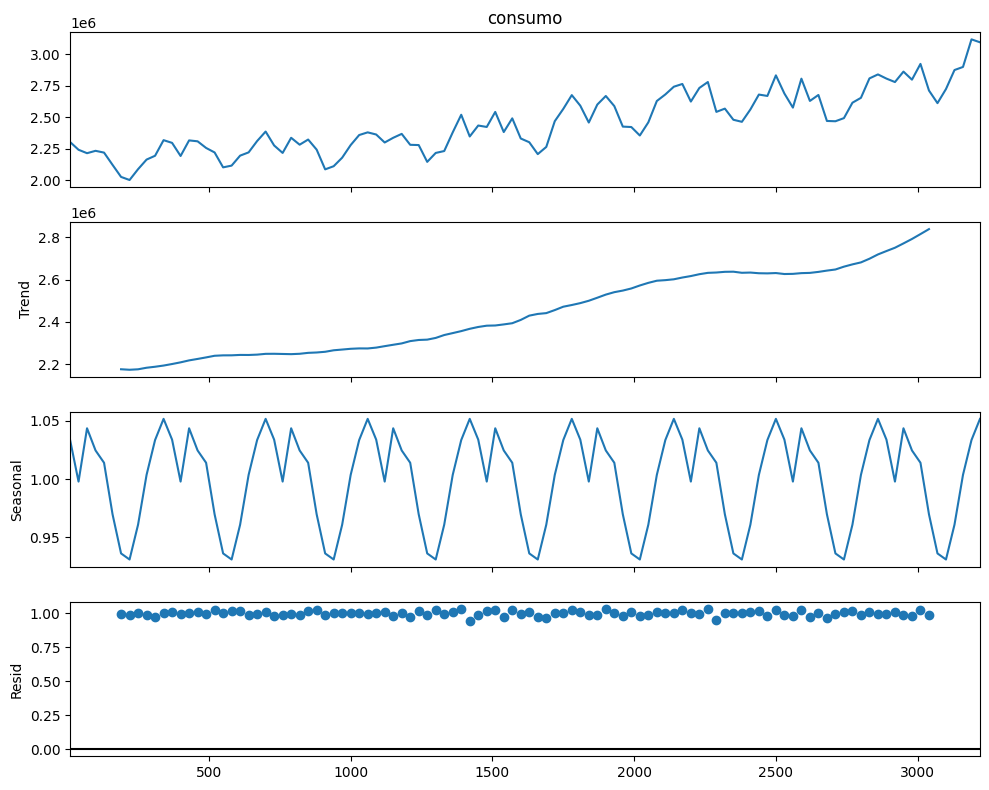

In [ ]:
resultado = seasonal_decompose(serie_nordeste_res, model='multiplicative', period=12)

plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()


#### Como a sazonalidade não ficou muito clara no gráfico, vamos visualizá-la com uma "lupa" do código a seguir:

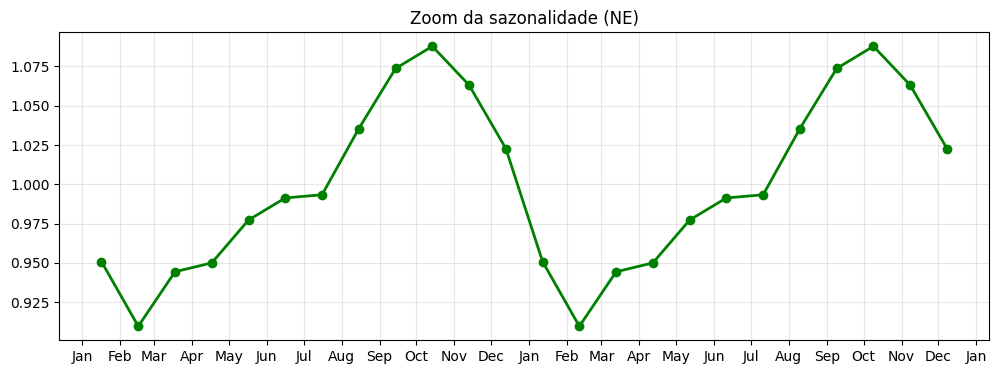

In [46]:
import matplotlib.dates as mdates

#Seleciona apenas os primeiros 24 meses (2 anos) para o gráfico não ficar apertado
sazonal_zoom = resultado.seasonal.iloc[:24]

plt.figure(figsize=(12, 4))
sazonal_zoom.plot(marker='o', color='green', linewidth=2)

# Formata o eixo X para mostrar o nome dos meses 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('Zoom da sazonalidade (NE)')
plt.grid(True, alpha=0.3)
plt.show()

#### Principais obervações:

1 - Há uma tendência de crescimento no consumo de energia residencial na região NE, o que se observa no gráfico da tendência.

2 - O gráfico da sazonalidade revela que o consumo de energia residencial tende a aumentar a partir do mês de fevereiro, atingindo seu pico no mês de outubro. O nível do consumo de energia apresenta aumento mais acentuado a partir de julho, e começa a decair em outubro. 

3 - Identicamos um vale profundo no mês de fevereiro, o que é contraintuitivo, pois este é um dos meses mais quentes em todo o país. Uma possível explicação para este fenômeno é que seja um reflexo do menor número de dias desse mês em comparação aos demais, o que reduz o volume total de energia contabilizado (efeito calendário).

4 - De setembro a dezembro, o Nordeste sofre o efeito B-R-Ó BRÓ (UOL, 2024), fenômeno climático que provoca calor extremo da região. As consequências deste fenômeno regional se refletem neste gráfico da sazonalidade, uma vez que os meses do B-R-Ó BRÓ apresentam um consumo elevado de energia residencial.

5 - O gráfico de resíduos apresenta-se estabilizado em torno de 1.0, indicando que o modelo multiplicativo foi capaz de capturar a maior parte da variabilidade da série. Pequenas flutuações residuais observadas sugerem eventos estocásticos (como variações climáticas extremas ou mudanças tarifárias pontuais) que não seguem o padrão sazonal típico.


### Decomposição da região Sudeste

In [47]:
filtro = (df_regioes['regiao'] == 'Sudeste') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_sudeste_res = df_regioes[filtro]['consumo']

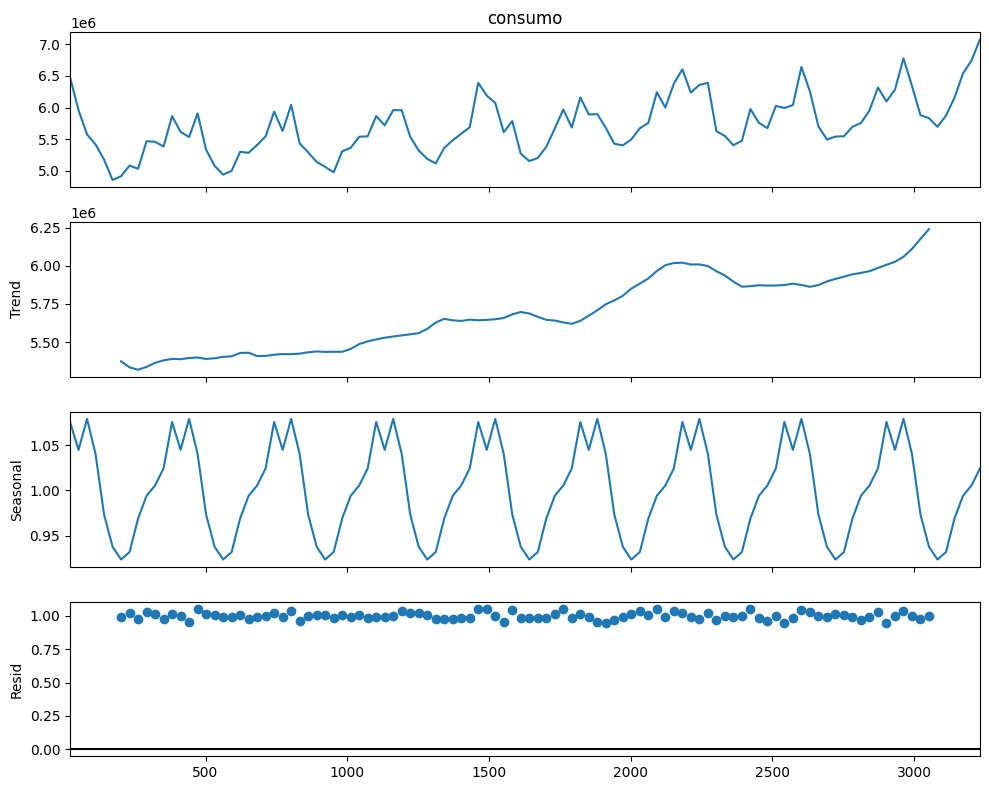

In [48]:
resultado = seasonal_decompose(serie_sudeste_res, model='multiplicative', period=12)

plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

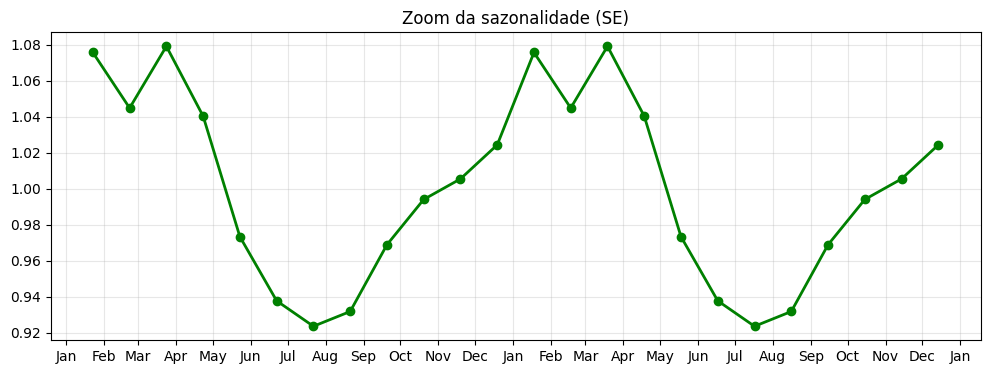

In [ ]:
sazonal_zoom = resultado.seasonal.iloc[:24]

plt.figure(figsize=(12, 4))
sazonal_zoom.plot(marker='o', color='green', linewidth=2)

# Formata o eixo X para mostrar o nome dos meses 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('Zoom da sazonalidade (Sudeste)')
plt.grid(True, alpha=0.3)
plt.show()

#### Pontos observados:

Na região Sudeste há um contraste componente sazonal em comparação com a região Nordeste. Os meses de pico de consumo de energia são os próximos ao Carnaval, justamente quando a região é atingida por temperaturas elevadas. Portanto, o componente sazonal parece ser explicado em grande parte por fenômenos climáticos.

Como percebido na região Nordeste, o consumo de energia residencial apresenta tendência de crescimento no Sudeste, embora um pouco menos linear que na região nordestina.

### Decomposição da região Centro-Oeste

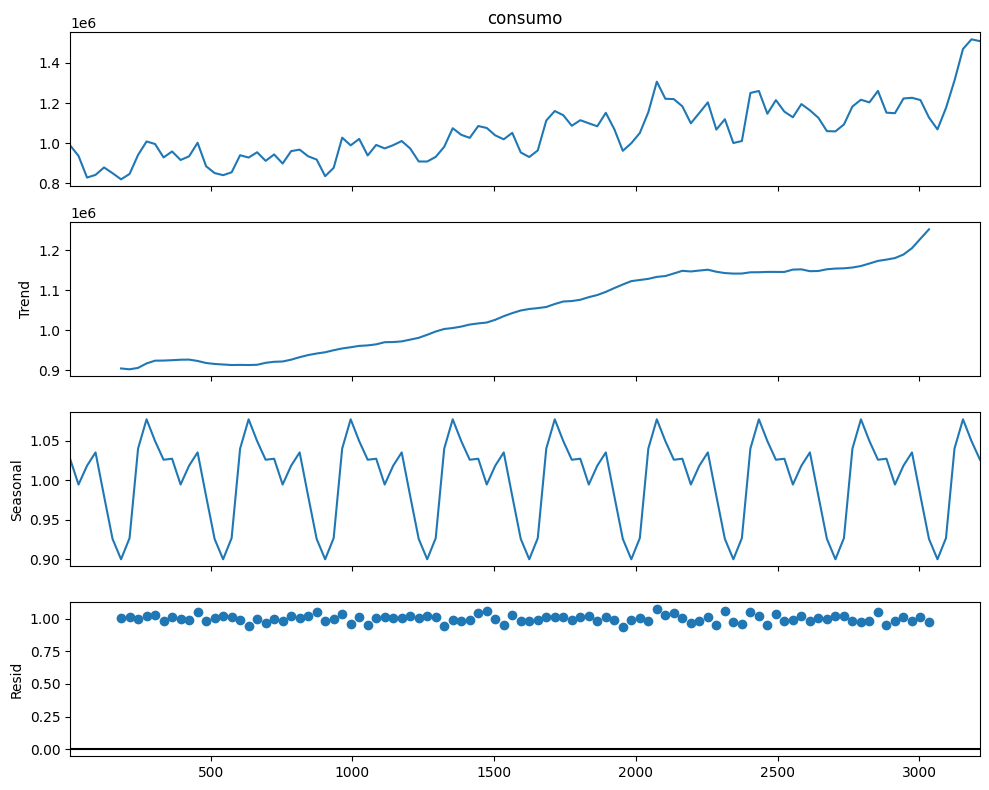

In [51]:
filtro = (df_regioes['regiao'] == 'Centro-Oeste') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_centroOeste_res = df_regioes[filtro]['consumo']

 
resultado = seasonal_decompose(serie_centroOeste_res, model='multiplicative', period=12)

plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

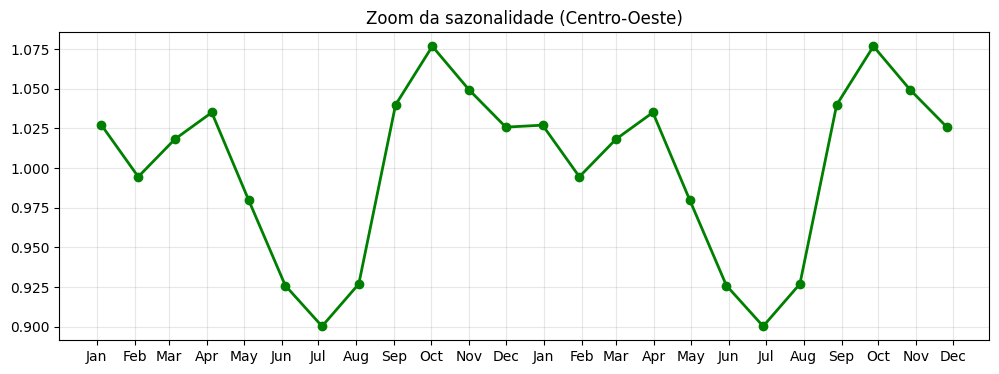

In [53]:
sazonal_zoom = resultado.seasonal.iloc[:24]

plt.figure(figsize=(12, 4))
sazonal_zoom.plot(marker='o', color='green', linewidth=2)

# Formata o eixo X para mostrar o nome dos meses 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('Zoom da sazonalidade (Centro-Oeste)')
plt.grid(True, alpha=0.3)
plt.show()

### Decomposição da região Sul

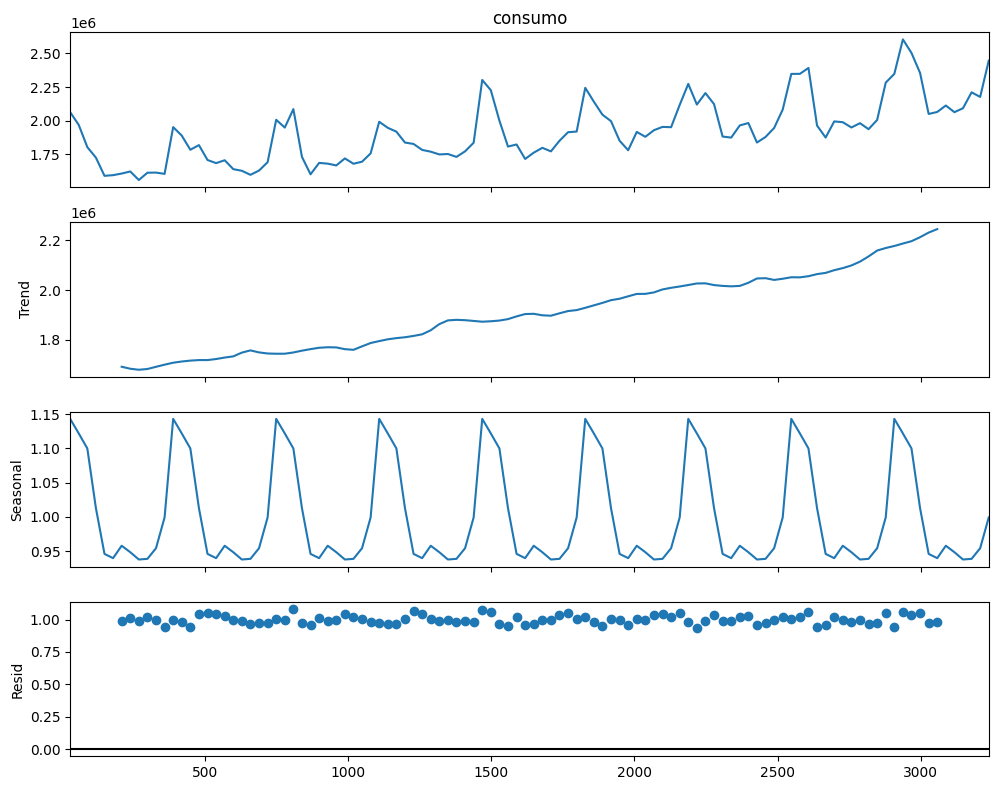

In [54]:
filtro = (df_regioes['regiao'] == 'Sul') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_sul_res = df_regioes[filtro]['consumo']

 
resultado = seasonal_decompose(serie_sul_res, model='multiplicative', period=12)


plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

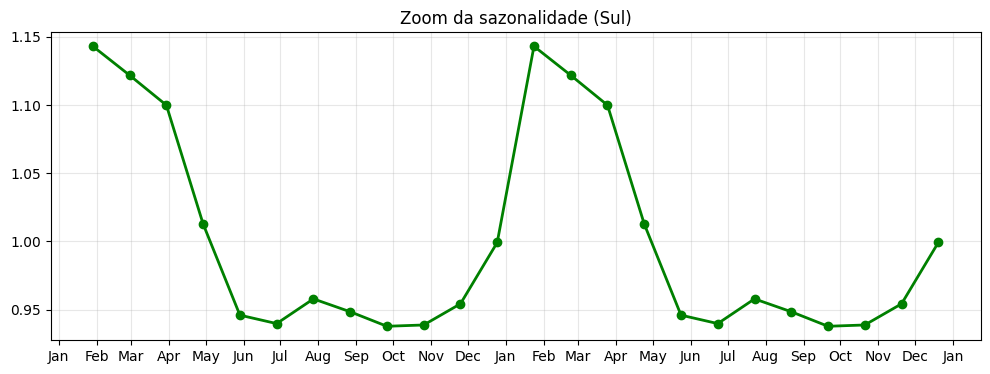

In [55]:
sazonal_zoom = resultado.seasonal.iloc[:24]

plt.figure(figsize=(12, 4))
sazonal_zoom.plot(marker='o', color='green', linewidth=2)

# Formata o eixo X para mostrar o nome dos meses 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('Zoom da sazonalidade (Sul)')
plt.grid(True, alpha=0.3)
plt.show()

### Decomposição da região Norte

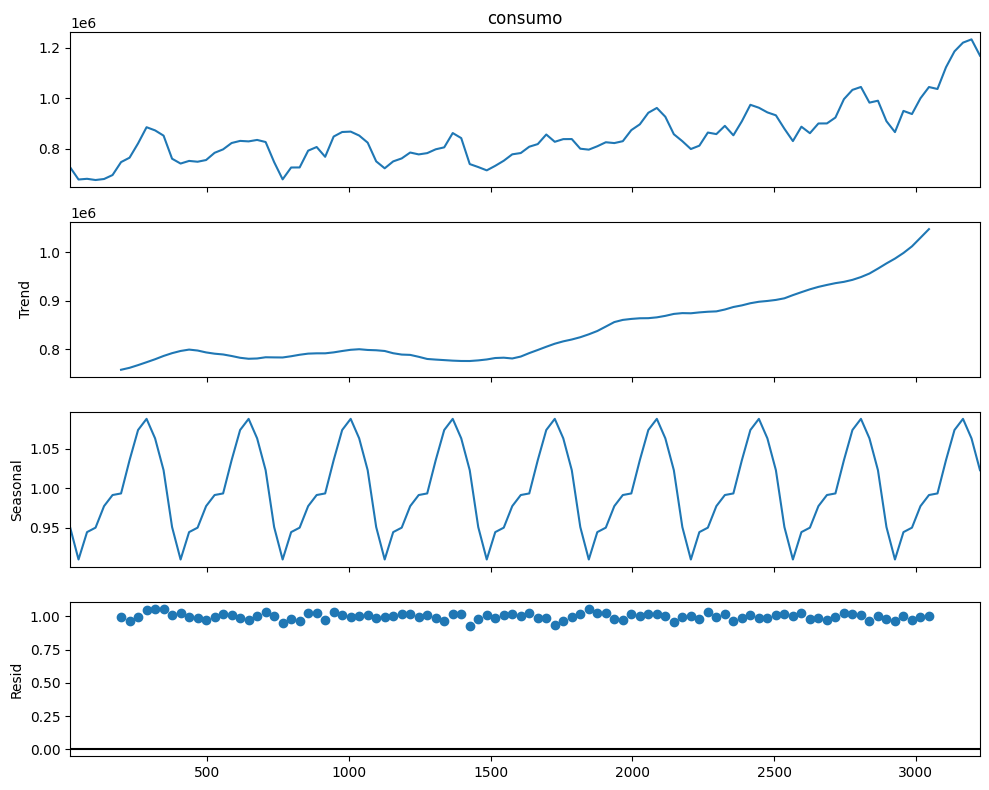

In [56]:
filtro = (df_regioes['regiao'] == 'Norte') & (df_regioes['tipo_consumo'] == 'Residencial')
serie_norte_res = df_regioes[filtro]['consumo']


resultado = seasonal_decompose(serie_norte_res, model='multiplicative', period=12)

plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.show()

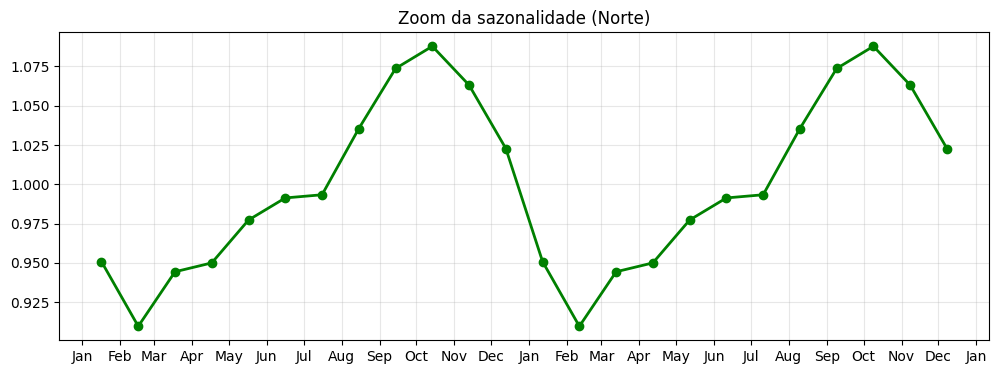

In [57]:
sazonal_zoom = resultado.seasonal.iloc[:24]

plt.figure(figsize=(12, 4))
sazonal_zoom.plot(marker='o', color='green', linewidth=2)

# Formata o eixo X para mostrar o nome dos meses 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('Zoom da sazonalidade (Norte)')
plt.grid(True, alpha=0.3)
plt.show()

É interessante notar que o gráfico da sazonalidade da região Norte se assemelha bastante com a análise visual deste mesmo componente da regisão Nordeste. Esse fato se explica porque a região Norte também sofre os efeitos do B-R-O-Bró.

# Analisando a região Nordeste, a região-alvo deste projeto

In [6]:
df_ne = pd.read_csv("datasets/consumo_energia_nordeste_detalhado.csv")

In [7]:
df_ne.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5832 entries, 0 to 5831
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ano           5832 non-null   int64 
 1   mes           5832 non-null   int64 
 2   sigla_uf      5832 non-null   object
 3   tipo_consumo  5832 non-null   object
 4   consumo       5832 non-null   int64 
 5   data          5832 non-null   object
dtypes: int64(3), object(3)
memory usage: 273.5+ KB


In [8]:
df_ne.head()

,ano,mes,sigla_uf,tipo_consumo,consumo,data
0,2015,1,AL,Residencial,116536,2015-01-01
1,2015,1,AL,Total,433782,2015-01-01
2,2015,1,AL,Outros,74383,2015-01-01
3,2015,1,AL,Industrial,176834,2015-01-01
4,2015,1,AL,Comercial,66029,2015-01-01


#### Como este dataset é derivado do anterior, com todas as regiões, sabemos que as variáveis contêm dados saudáveis. Só vamos verificar se h[a inconsistências na coluna categórica **sigla_uff**.

In [58]:
df_ne["sigla_uf"].unique()

array(['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'], dtype=object)

### Análise exploratória da base de dados do Nordeste

#### - Qual é o comportamento do consumo médio residencial de energia em cada estado ao longo dos anos?

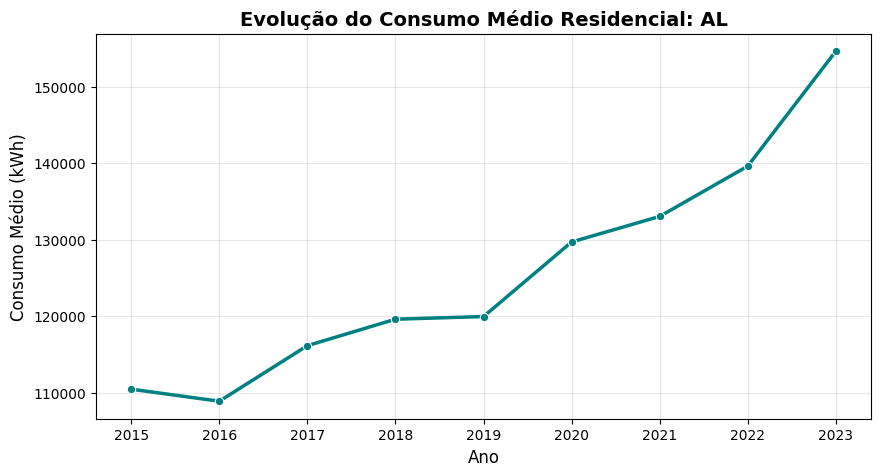

------------------------------


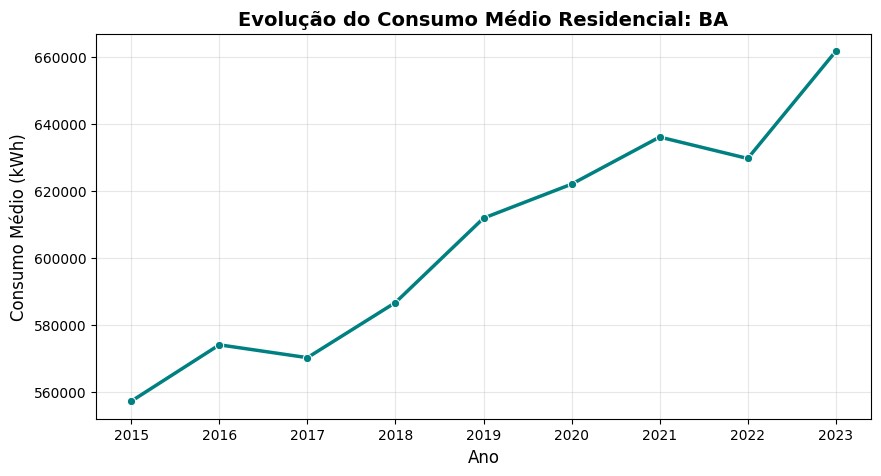

------------------------------


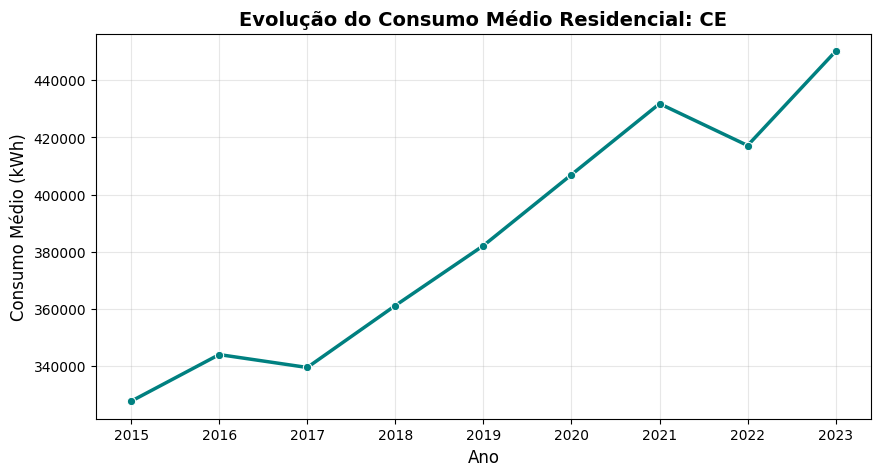

------------------------------


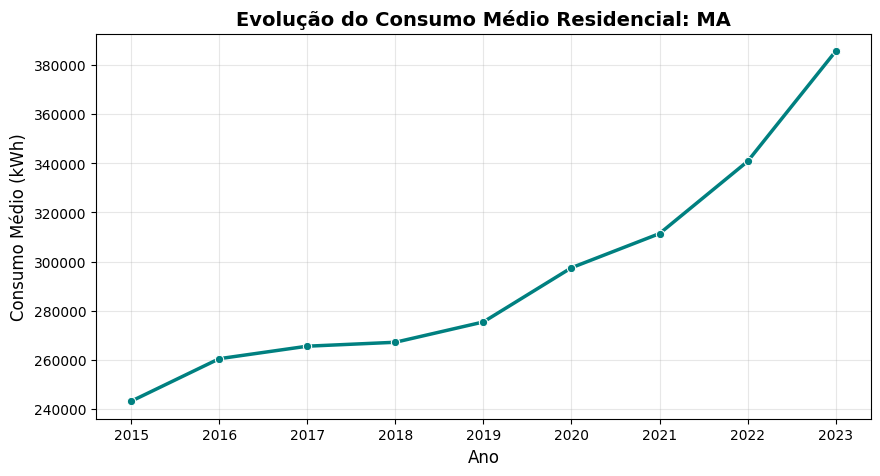

------------------------------


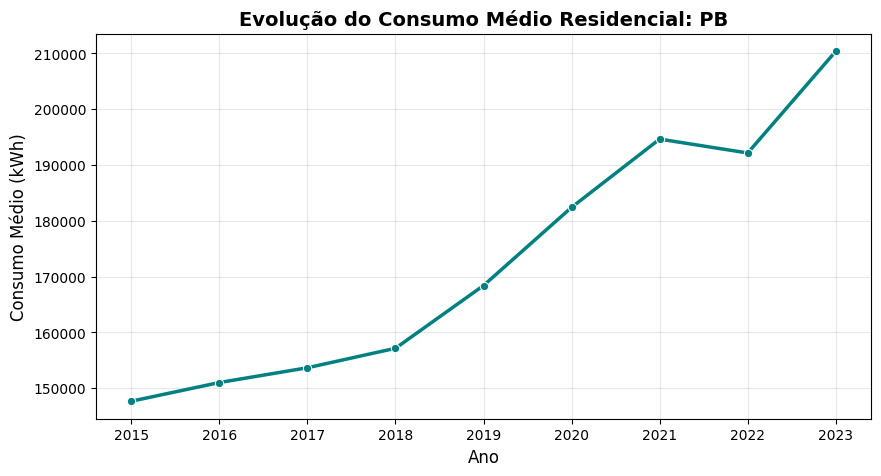

------------------------------


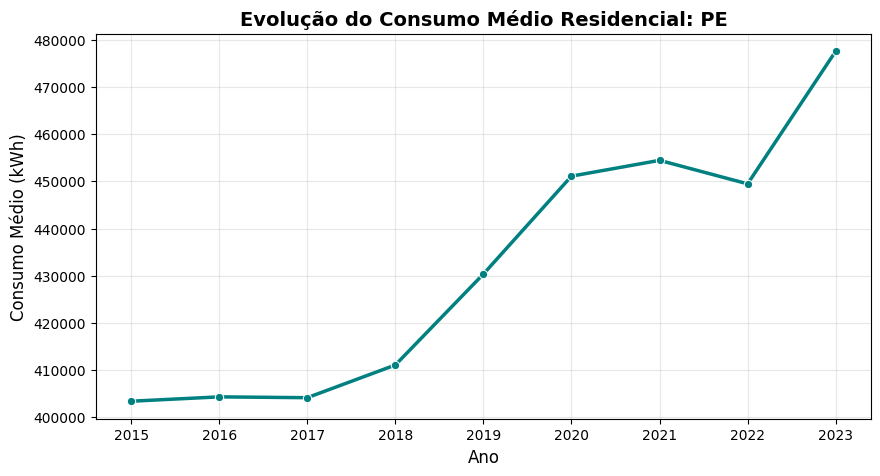

------------------------------


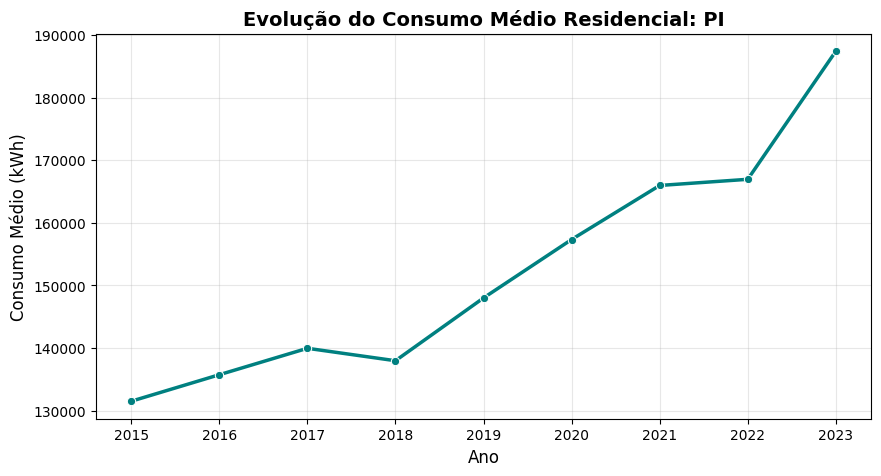

------------------------------


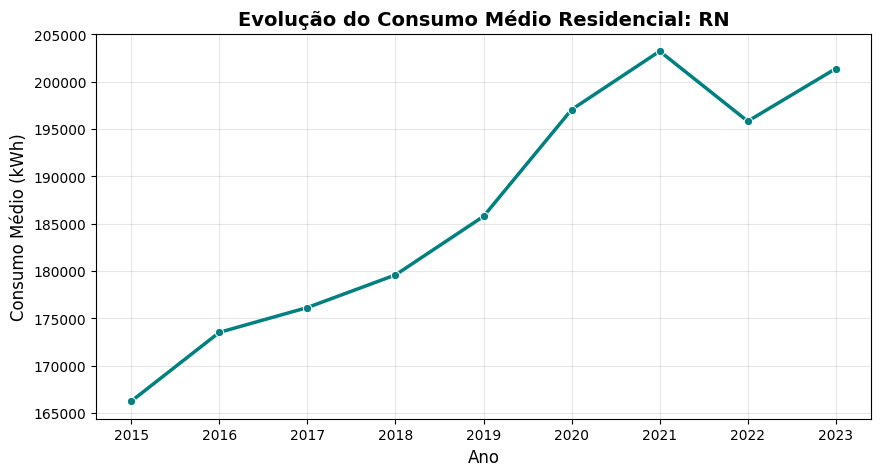

------------------------------


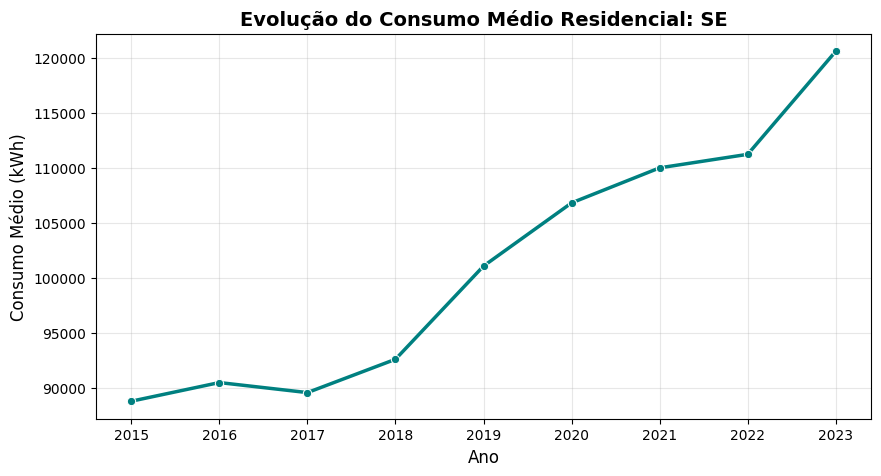

------------------------------


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos a média anual (igual ao anterior)
df_anual = df_ne[df_ne['tipo_consumo'] == 'Residencial'].groupby(['sigla_uf', 'ano'])['consumo'].mean().reset_index()

# 2. Loop para gerar um gráfico individual para cada estado
for uf in df_anual['sigla_uf'].unique():
    # Filtra os dados apenas do estado atual
    dados_uf = df_anual[df_anual['sigla_uf'] == uf]
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=dados_uf, x='ano', y='consumo', marker='o', color='teal', linewidth=2.5)
    
    # Customização do gráfico
    plt.title(f'Evolução do Consumo Médio Residencial: {uf}', fontsize=14, fontweight='bold')
    plt.xlabel('Ano', fontsize=12)
    plt.ylabel('Consumo Médio (kWh)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(dados_uf['ano'].unique()) # Garante que todos os anos apareçam no eixo X
    
    # DICA: Descomente a linha abaixo se quiser salvar os gráficos na sua pasta de trabalho
    # plt.savefig(f'grafico_consumo_{uf}.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    print("-" * 30)

Ao analisar o consumo médio residencial ao longo dos anos, observa-se que a maioria dos estados do Nordeste apresentou uma desaceleração ou queda no ritmo de consumo de energia elétrica. No entanto, os estados do Maranhão e de Alagoas divergiram desse padrão regional, sendo os únicos a apresentar um crescimento mais acentuado e constante durante o período.

Essa trajetória sugere que esses dois estados foram menos impactados pelos efeitos da crise hídrica no consumo doméstico em comparação aos demais estados da região, mantendo a tendência de alta mesmo nos anos de maior estresse hídrico e tarifário.

## Análise dos componentes da série temporal de cada estado nordestino

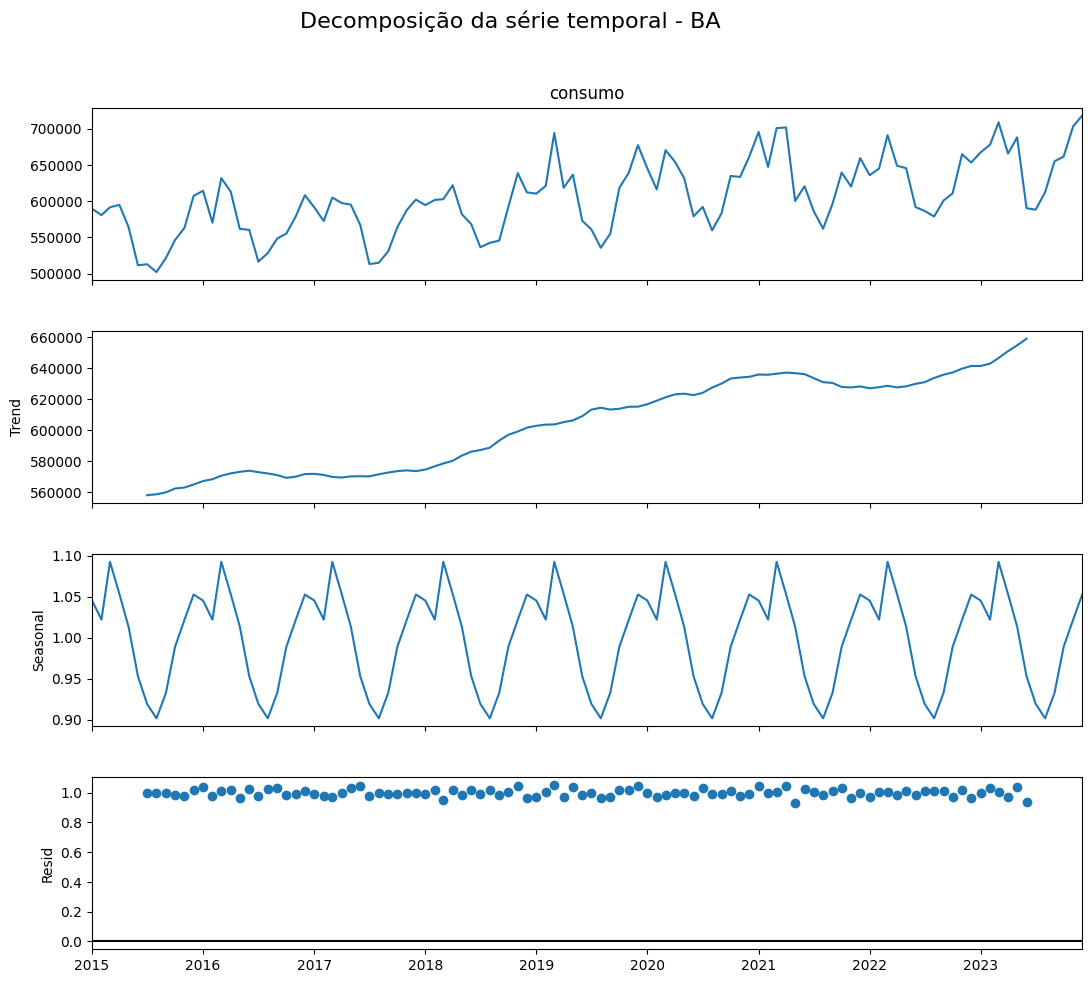

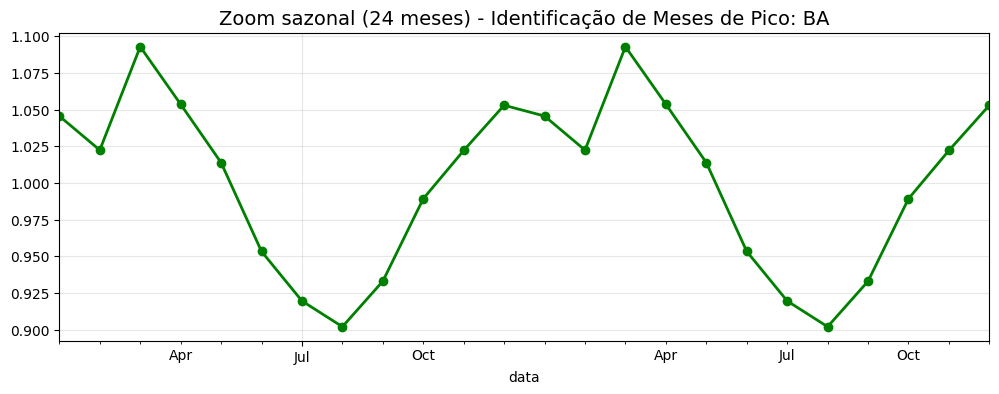

In [ ]:
uf_alvo = 'BA' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

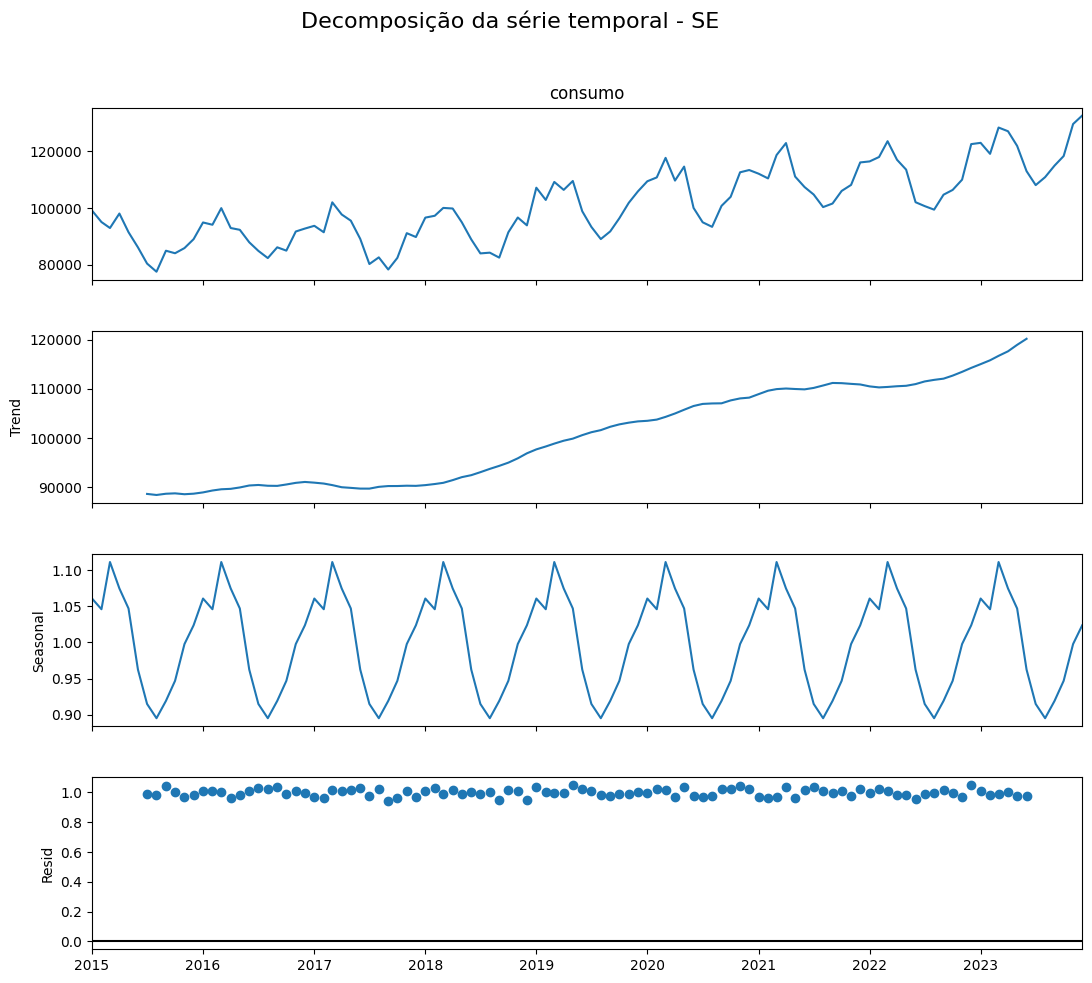

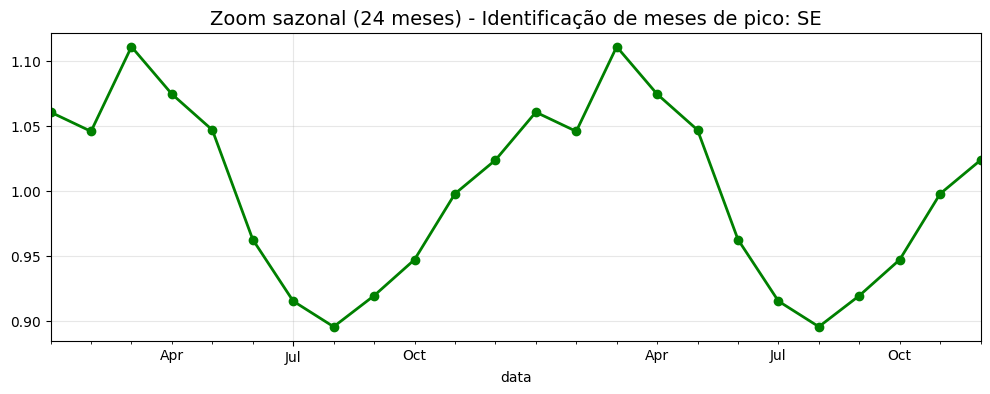

In [ ]:
uf_alvo = 'SE' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

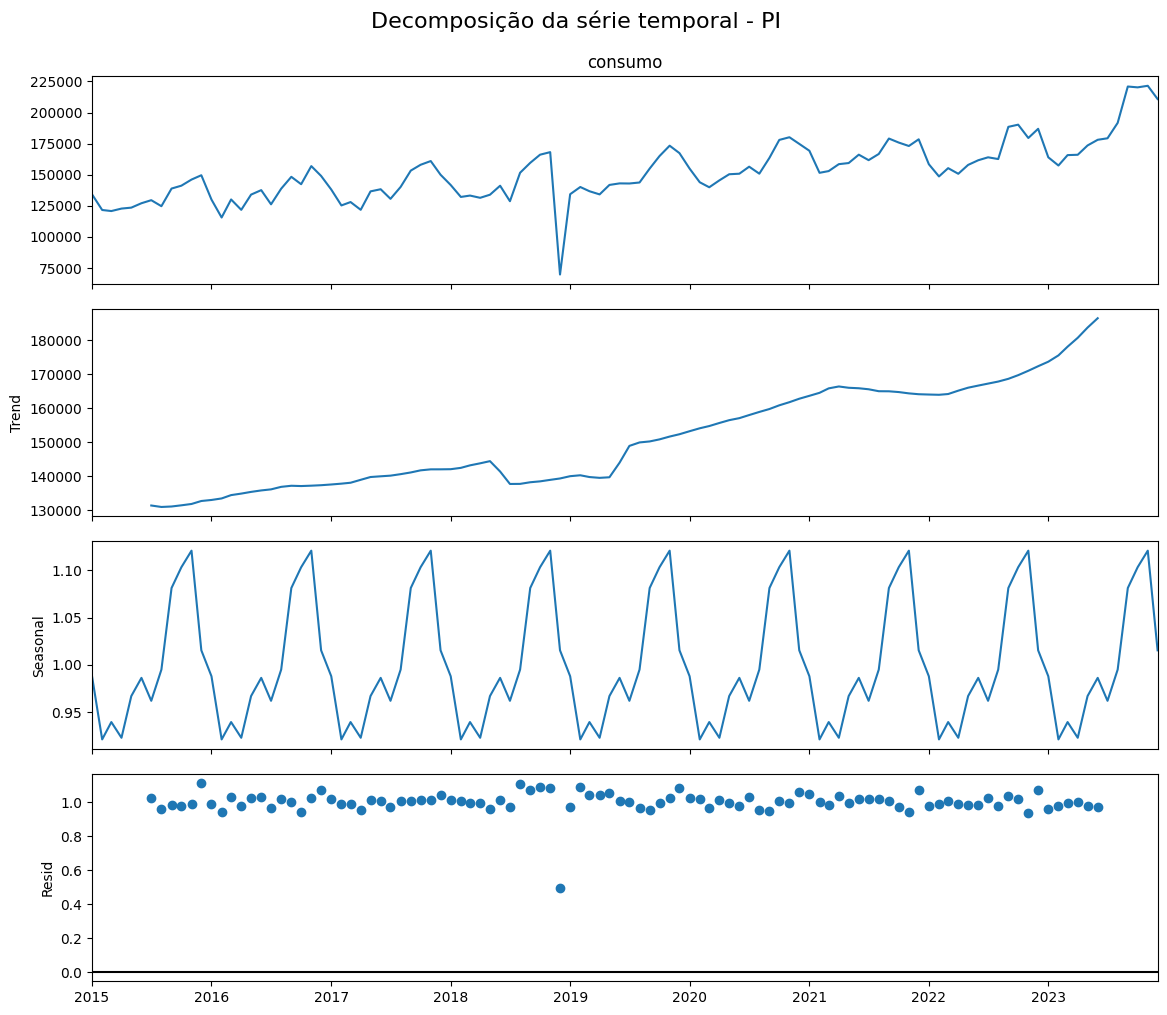

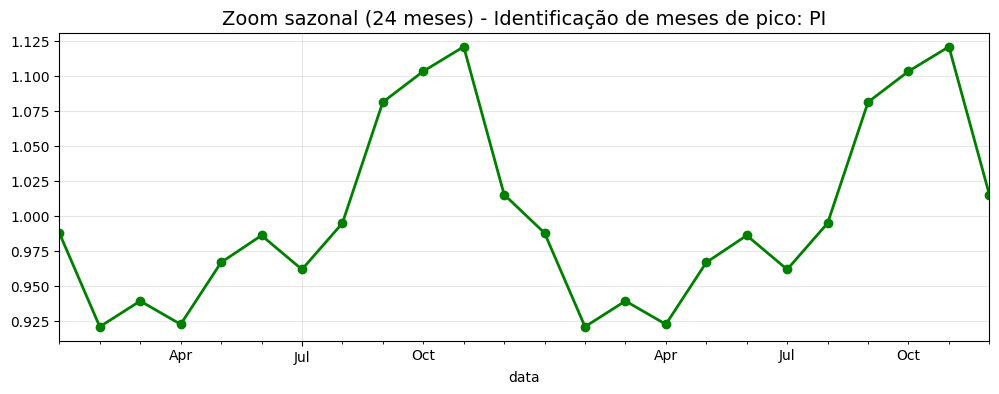

In [59]:
uf_alvo = 'PI' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

Na decomposição da série do Piauí, destaca-se uma anomalia severa no componente residual próxima ao ano de 2019, com o índice atingindo 0.50. Este valor indica que o consumo registrado foi 50% inferior à expectativa do modelo. Dada a magnitude da queda e a ausência de eventos climáticos ou econômicos que justifiquem tal retração, a hipótese mais provável é de uma inconsistência pontual no faturamento ou no reporte dos dados brutos durante o período de transição da concessionária de energia local.

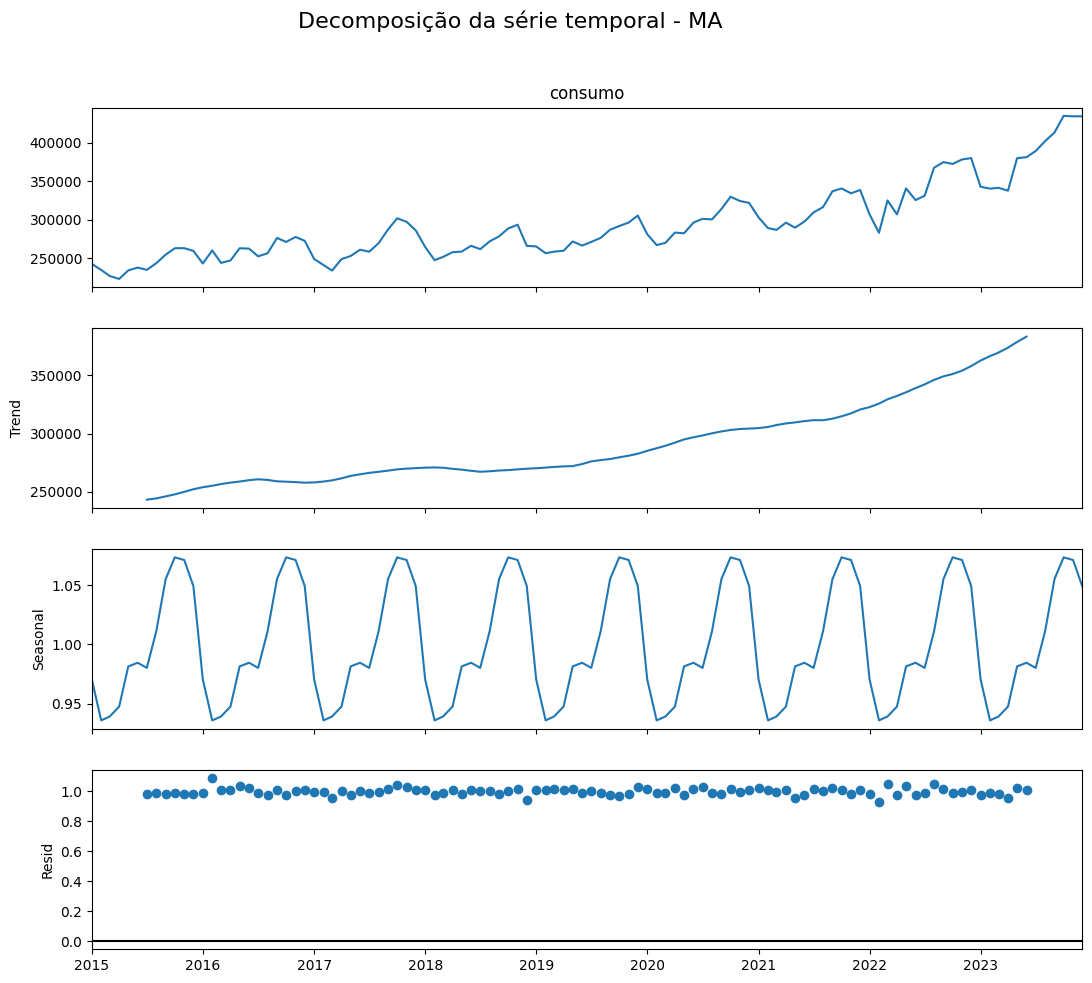

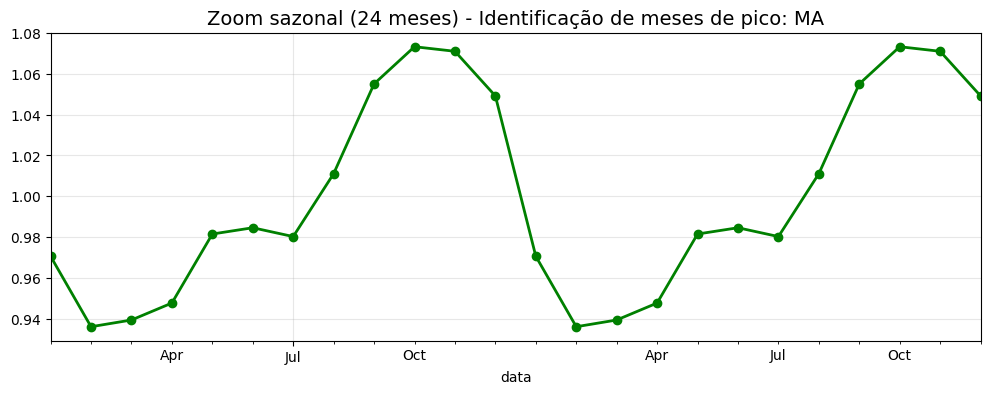

In [15]:
uf_alvo = 'MA' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

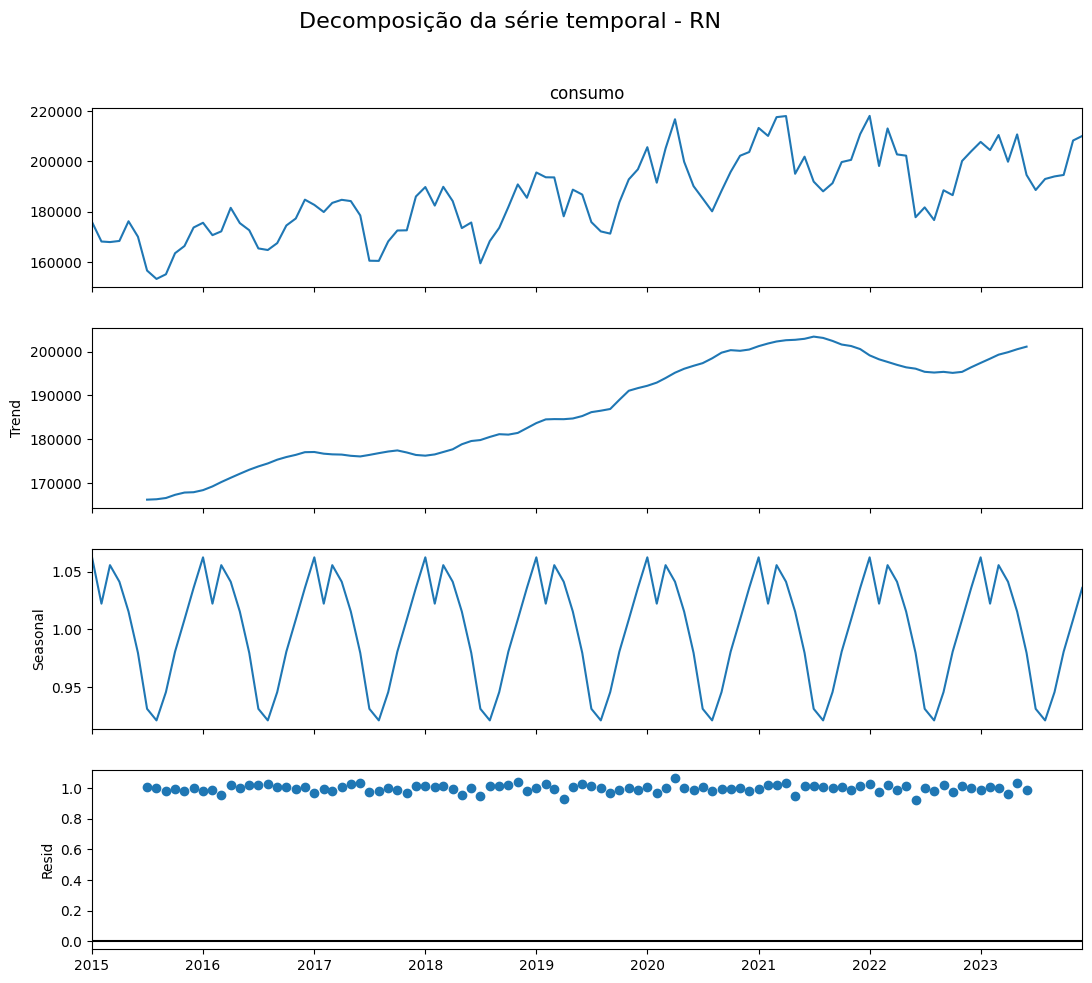

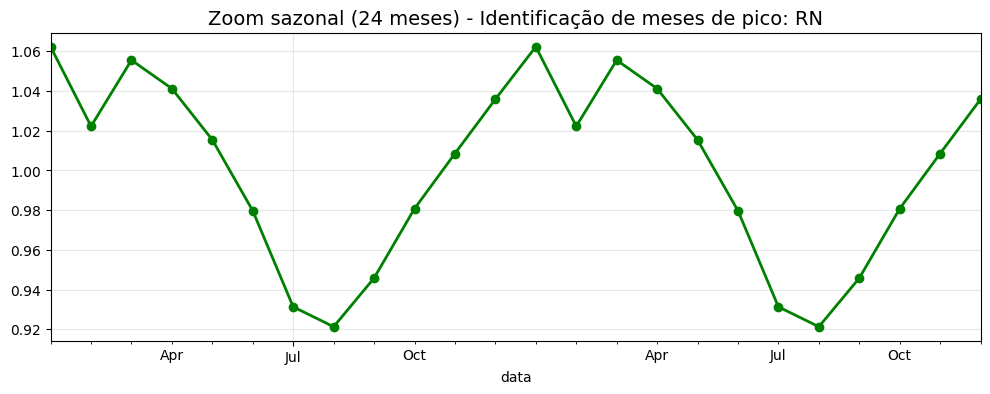

In [16]:
uf_alvo = 'RN' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

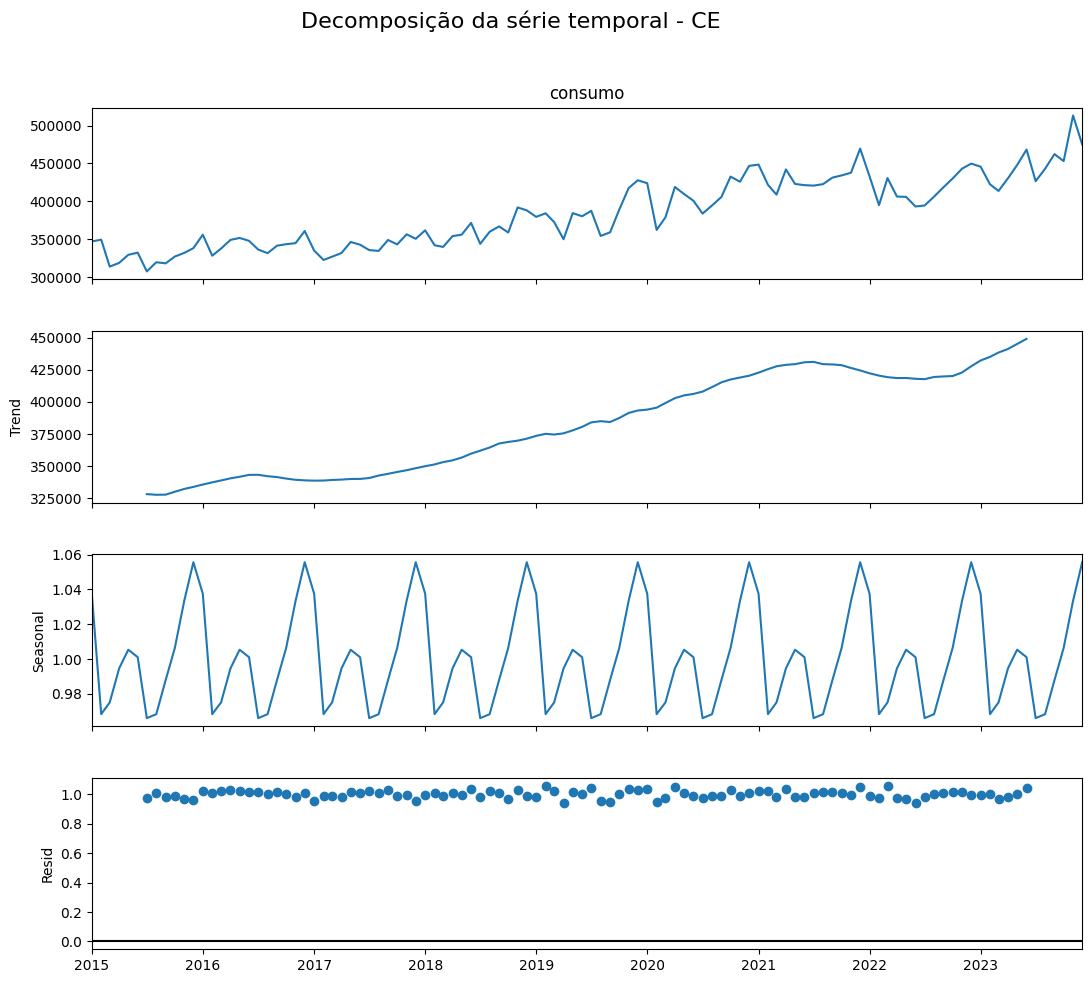

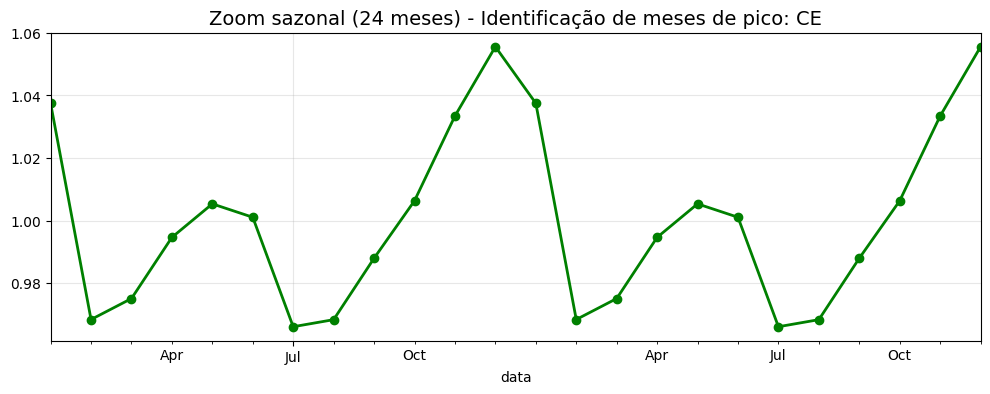

In [17]:
uf_alvo = 'CE' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

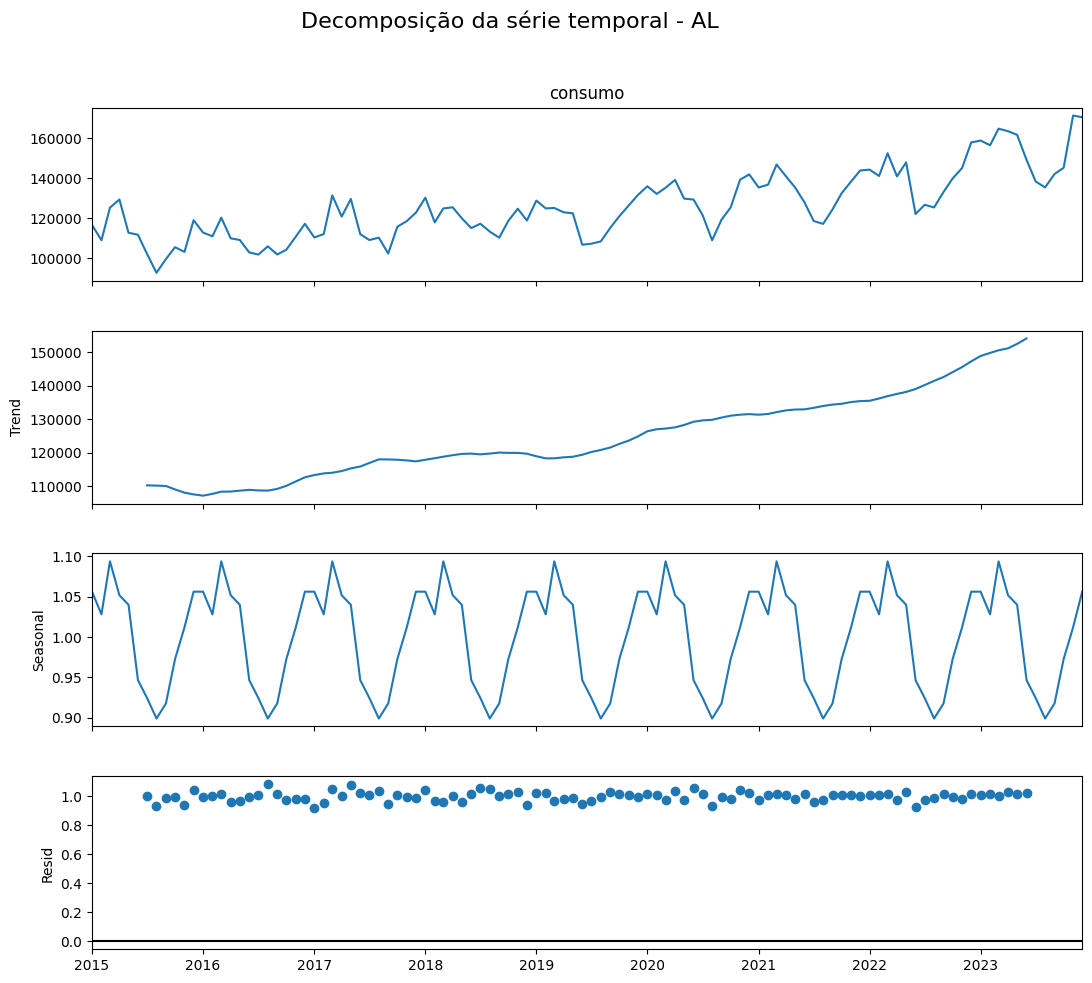

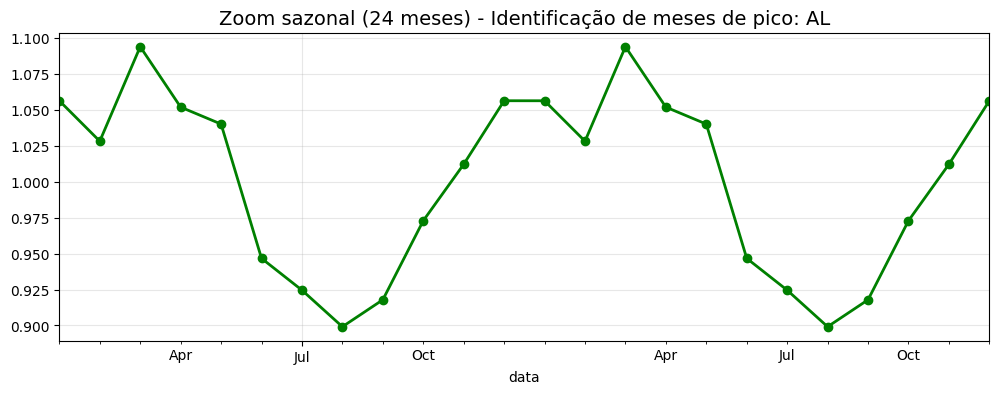

In [19]:
uf_alvo = 'AL' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

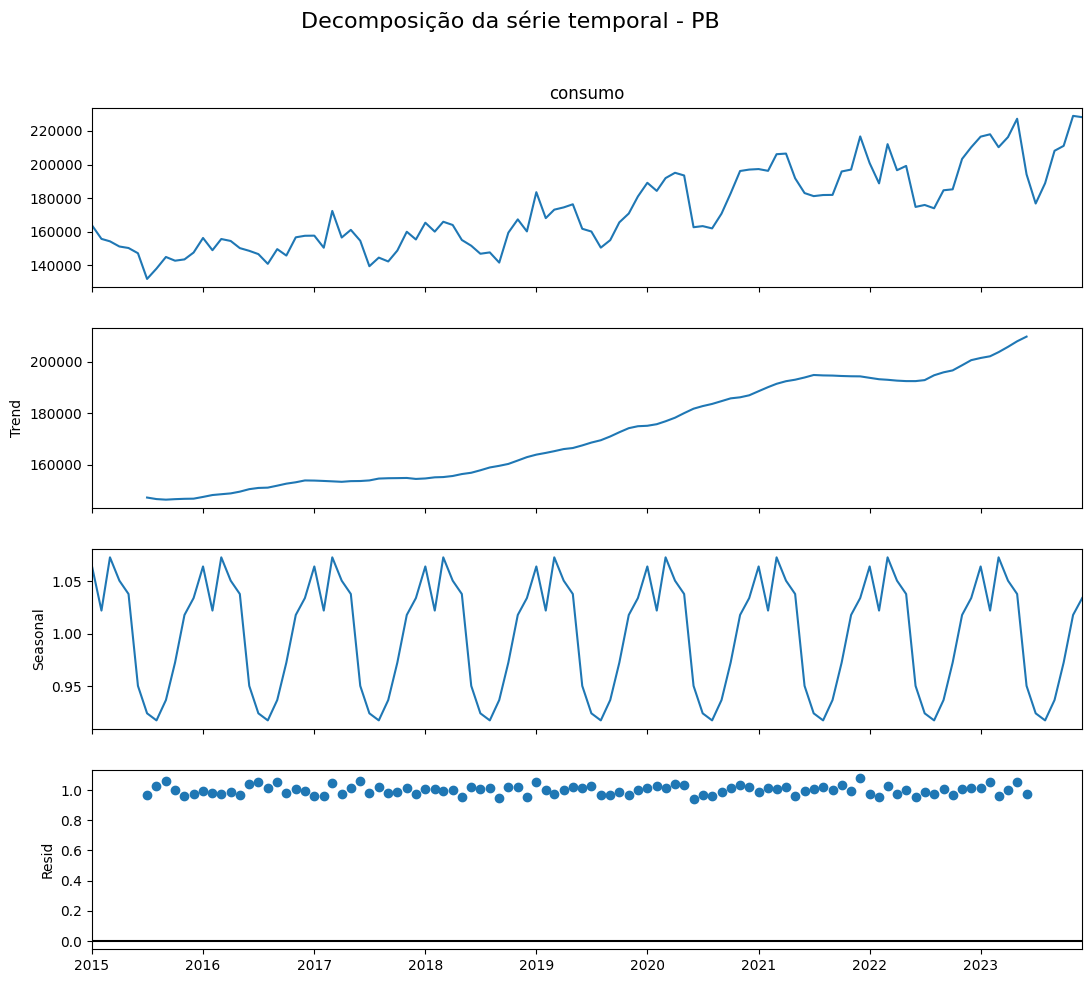

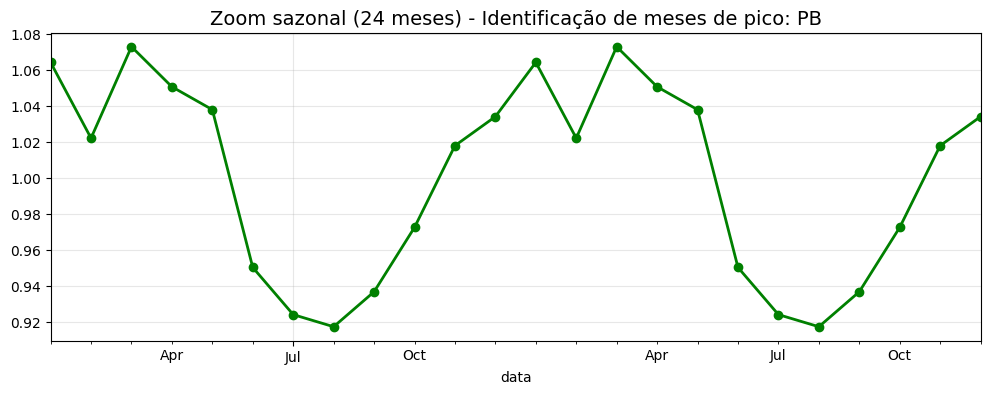

In [20]:
uf_alvo = 'PB' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

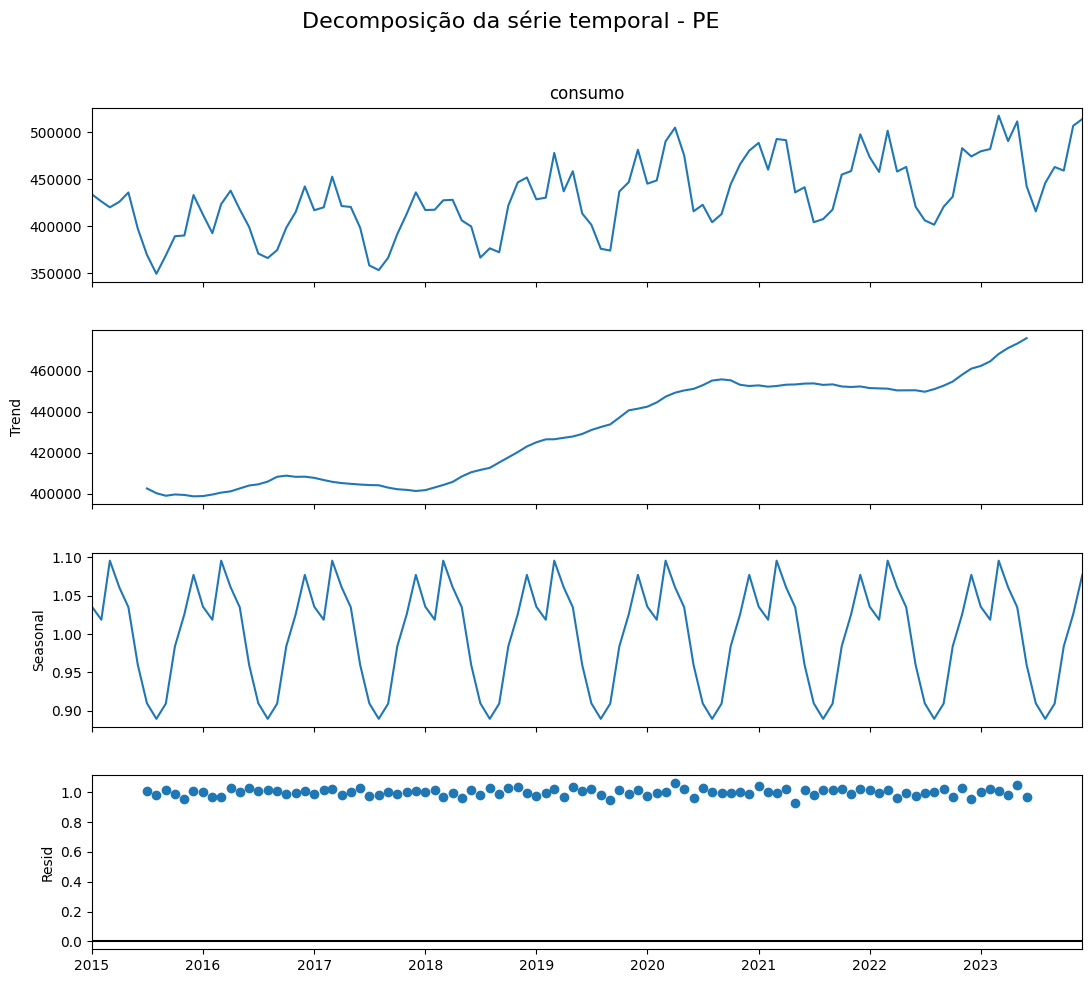

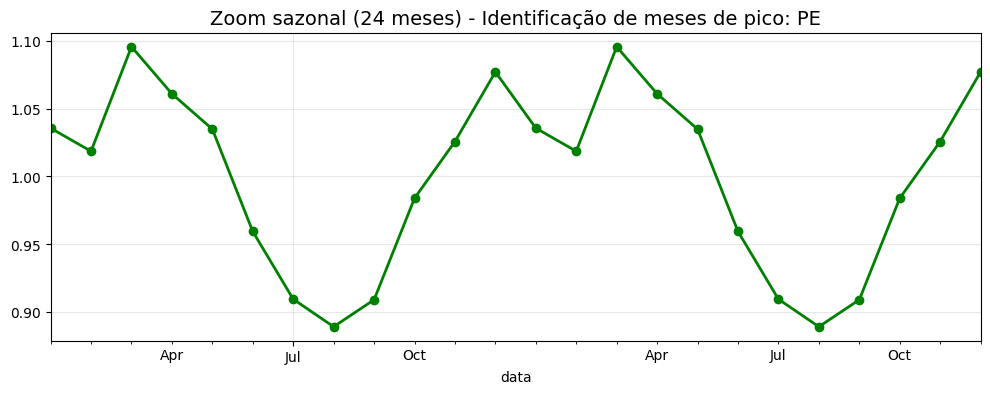

In [21]:
uf_alvo = 'PE' 
df_uf = df_ne[(df_ne['sigla_uf'] == uf_alvo) & (df_ne['tipo_consumo'] == 'Residencial')].copy()
df_uf['data'] = pd.to_datetime(df_uf['data'])
serie_uf = df_uf.set_index('data')['consumo'].resample('MS').mean()

resultado = seasonal_decompose(serie_uf, model='multiplicative')

fig = resultado.plot()
fig.set_size_inches(12, 10)
fig.suptitle(f'Decomposição da série temporal - {uf_alvo}', fontsize=16, y=1.02)
plt.show()

# "Zoom" do componente de sazonalidade para compreender melhor esse comportamento e quanto ele acontece
plt.figure(figsize=(12, 4))
# Pegamos 2 anos (24 meses) para identificar os meses com clareza
resultado.seasonal.iloc[:24].plot(marker='o', color='green', linewidth=2)

plt.title(f'Zoom sazonal (24 meses) - Identificação de meses de pico: {uf_alvo}', fontsize=14)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b coloca o nome do mês
plt.grid(True, alpha=0.3)
plt.show()

### Panorama da decomposição por estado da região Nordeste

| Estado | Tendência (2015-2023) | Meses de pico (Sazonalidade) | Meses de vale (Sazonalidade) |
| :--- | :--- | :--- | :--- |
| **Maranhão** | Crescimento | Outubro / Novembro (crescimento do consumo de julho a outubro)| Fevereiro / Julho (queda do consumo de novembro até fevereiro)|
| **Piauí** | Crescimento irregular (atenção para outlier) / | Novembro /Agosto (crescimento de julho até novembro ) | Fevereiro / Abril (queda de novmebro a dezembro)|
| **Ceará** | Crescimento | Dezembro | Fevereiro / Julho |
| **Rio Grande do Norte** | Crescimento | Janeiro / Março (aumento acentuado do consumo de agosto até janeiro) | Agosto (queda do consumo de março até julho) |
| **Paraíba** | Crescimento | Janeiro (crescimento acentuado dos meses de agosto até janeiro, e também de fevereiro a março) | Fevereiro (queda acentuada no consumo de março até agosto) |
| **Pernambuco** | Crescimento, mas com alugns pontos de desaceleração e queda | Dezembro / Março (crescimento muito acentuado de setembro a dezembro)| Fevereiro e agosto (redução drástica do crescimento de abril até agosto) |
| **Alagoas** | Crescimento | Março (aumento acentuado no consumo de agosto até dezembro; de dezembro a janeiro o consumo é constante) | Agosto (queda acentuada no consumo de março a agosto) |
| **Sergipe** | Crescimento | Entre março e abril | Agosto |
| **Bahia** | Crescimento | Dezembro / Março (crescimento acentuado e contínuo de agosto a janeiro e de fevereiro em março) | Agosto |

### Análises da decomposição temporal dos estados do Nordeste:

* O "bloco do calor de interior" (MA, PI, CE):

Nestes estados, o "vilão" do orçamento familiar é o final do ano, apresentando como meses de pico de consumo energético residencial os meses de outubro a dezembro.

O consumo começa a escalar em julho, justamente quando as chuvas cessam e o calor do B-R-O-Bró começa a se intensificar.

Diante disso, as famílias precisam estar financeiramente preparadas para um aumento de consumo que dura quase um semestre inteiro (julho a dezembro).

* O "bloco do litoral e turismo" (RN, PB, PE, AL, SE, BA):
Aqui a dinâmica é outra. O consumo de energia residencial é mais intenso na virada do ano e no primeiro trimestre, apresentando como picos os meses de dezembro a março.

É curioso como agosto aparece como o ponto mais baixo para quase todos esses estados. No litoral nordestino, é um mês de ventos fortes e temperaturas mais amenas (o "inverno" local), o que reduz drasticamente a necessidade de refrigeração.

#### Nota importante sobre o Piauí:

Apesar da tendência de crescimento no consumo energético, o outlier observado no componente residual, correspondente a 2019, distorce a linearidade da tendência e pode "enganar" modelos preditivos simples. **Será necessário tratar esse dado antes de construir o modelo.**

### Referências bibliográficas



HYNDMAN, R. J.; ATHANASOPOULOS, G. Forecasting: principles and practice. 3. ed. Melbourne: OTexts, 2021. Disponível em: https://otexts.com/fpp3/. Acesso em: 25 mar. 2026.

UOL. O que é o 'B-R-O-Bró', que castiga o Nordeste com 'calorão impiedoso'? UOL, São Paulo, 25 set. 2024. Disponível em: https://noticias.uol.com.br/meio-ambiente/ultimas-noticias/redacao/2024/09/25/o-que-e-o-b-r-o-bro-que-castiga-o-nordeste-com-calorao-impiedoso.htm. Acesso em: 25 mar. 2026.
